# CNeuroMod QA — per-region atlas tSNR

Raincloud distributions of per-run, per-region tSNR extracted from the shared MNI152NLin2009cAsym combined atlas (Schaefer2018 cortex / Yeo-7 networks, Tian S3 subcortex, Nettekoven cerebellum — see `analysis/atlas_labels.py`), read from `output_data/tables/atlas_tsnr/`. Figures are written to `output_data/figures/atlas_tsnr/`.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np  # noqa: F401
import pandas as pd
import seaborn as sns

try:
    import ptitprince
    HAS_PTITPRINCE = True
except Exception:
    HAS_PTITPRINCE = False

# Paths are provided by `invoke run-notebooks` as environment variables.
# Figures go in output_data/figures/{FIG_NAME}/ (also the notebook's "already
# ran" sentinel); the per-region tables live in output_data/tables/atlas_tsnr/.
FIG_NAME = "atlas_tsnr"
OUTPUT_DIR = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data"))
FIG_DIR = OUTPUT_DIR / "figures" / FIG_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_tables(subdir):
    """Concatenate every non-empty TSV in output_data/<subdir>/."""
    frames = []
    for path in sorted((OUTPUT_DIR / subdir).glob("*.tsv")):
        try:
            frame = pd.read_csv(path, sep="\t")
        except (pd.errors.EmptyDataError, OSError):
            continue
        if not frame.empty:
            frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# --- House figure style (dataviz skill) --------------------------------------
# Colour is assigned by the job it does and checked with the skill's validator:
# per-region distributions are already labelled on the x-axis, so the marks use
# ONE recessive hue instead of a decorative rainbow (same convention as
# qc_measures.ipynb / tsnr_maps.ipynb).
HUE = "#2a78d6"      # single categorical hue (blue, slot 1)
INK = "#0b0b0b"      # primary ink
MUTED = "#898781"    # axis + tick labels (recessive)
GRID = "#e1e0d9"     # hairline gridline

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": MUTED,
    "axes.linewidth": 0.8,
    "axes.titlesize": 12,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.family": "sans-serif",
})


def style_axes(ax):
    """Recessive chrome: drop top/right spines, hairline y-grid, ticks behind."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    return ax


In [2]:
def raincloud(data, x, y, ax, color=None, ascending=True):
    """Half-violin + jittered strip in a single recessive hue (no boxplot).

    A full RainCloud stacks a half-violin, a boxplot, and a strip; we drop the
    box and compose the two remaining layers directly (ptitprince exposes
    `half_violinplot` and `stripplot`), with a seaborn fallback. The category is
    already named on the x-axis, so colour would carry no extra information; one
    hue keeps the ink recessive (dataviz skill).

    Categories are ordered along the x-axis by their median `y`: `ascending=True`
    (default) runs least-to-most left-to-right; pass `ascending=False` for tSNR,
    where higher is better, so the best sits on the left and the worst on the
    right (same convention as qc_measures.ipynb)."""
    color = HUE if color is None else color
    data = data[[x, y]].dropna()
    if data.empty:
        ax.set_title(f"no data for {y}")
        return ax
    order = (data.groupby(x)[y].median()
                 .sort_values(ascending=ascending).index.tolist())
    n = max(data[x].nunique(), 1)
    if HAS_PTITPRINCE:
        try:
            ptitprince.half_violinplot(x=x, y=y, data=data, order=order,
                                       palette=[color] * n, bw=.15, width=.9,
                                       ax=ax, orient="v", inner=None, offset=-.05)
            ptitprince.stripplot(x=x, y=y, data=data, order=order,
                                 palette=[color] * n, ax=ax, orient="v", move=.2,
                                 size=2, alpha=.65, edgecolor="white", linewidth=.3)
            if ax.get_legend():
                ax.get_legend().remove()
            return style_axes(ax)
        except Exception:
            ax.clear()
    sns.violinplot(data=data, x=x, y=y, ax=ax, order=order, color=color,
                   inner=None, cut=0)
    sns.stripplot(data=data, x=x, y=y, ax=ax, order=order, color=INK, size=2,
                  alpha=.35)
    return style_axes(ax)


In [3]:
regions = load_tables("tables/atlas_tsnr")
print(f"loaded {len(regions)} region-rows")
if regions.empty:
    print("No atlas-tSNR rows found — run `invoke run-atlas-tsnr` first "
          "(needs data access).")
regions.head()


loaded 41688 region-rows


,region_name,group,tsnr_mean,dataset,subject,session,task,run
0,7Networks_LH_Vis_1,cortex_Vis,24.979289,floc,1,1,fLoc,1
1,7Networks_LH_Vis_2,cortex_Vis,37.688079,floc,1,1,fLoc,1
2,7Networks_LH_Vis_3,cortex_Vis,33.164481,floc,1,1,fLoc,1
3,7Networks_LH_Vis_4,cortex_Vis,41.643214,floc,1,1,fLoc,1
4,7Networks_LH_Vis_5,cortex_Vis,39.282897,floc,1,1,fLoc,1


## tSNR by region group

One raincloud pooling nine distributions, ordered worst-to-best tSNR
left-to-right: the 7 Yeo networks (each pooling its ~400 Schaefer2018
cortical parcels), plus **Cerebellum** and **Central structures**, each
collapsed to a single per-run average across their parcels/subregions
(Nettekoven cerebellar parcels; Tian S3 putamen/thalamus/caudate). A
per-network or per-parcel breakdown would be unreadable in one panel — the
underlying TSV keeps full per-parcel/per-subregion granularity for anyone who
wants to re-slice it.

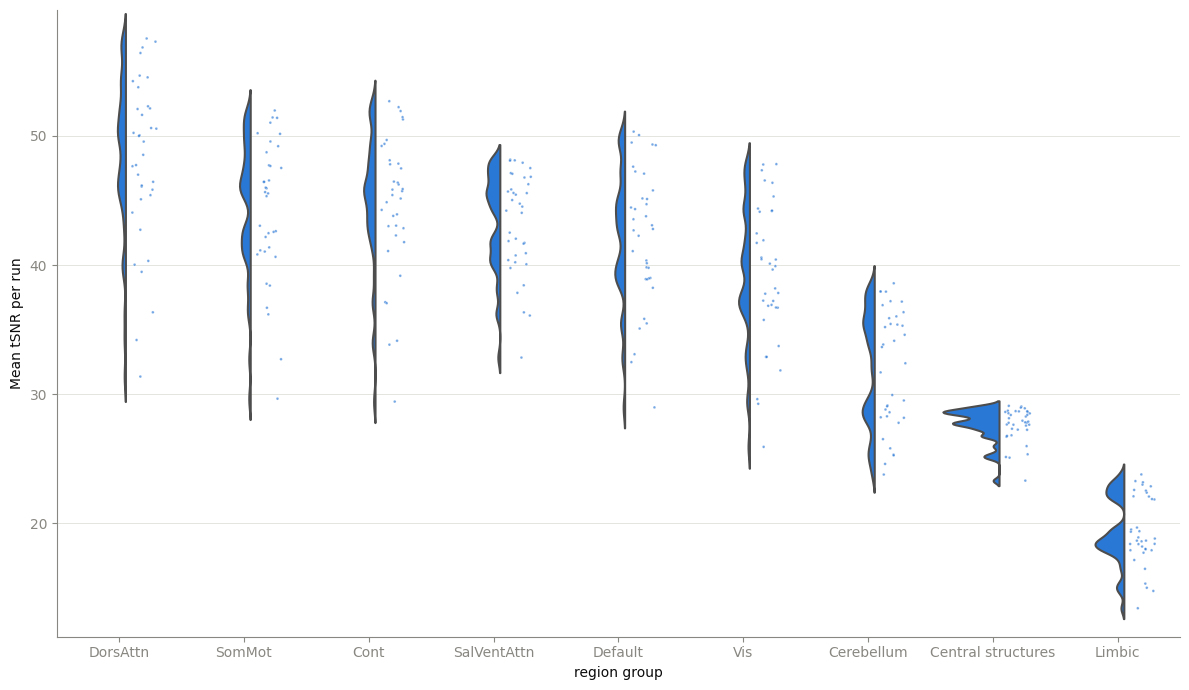

In [4]:
RUN_ID_COLS = ["dataset", "subject", "session", "task", "run"]


def average_group(regions, group_mask, category):
    """Collapse a group's per-parcel rows to one per-run average.

    Every category (cortex network, cerebellum, central structures) spans
    many parcels/subregions; each must become a single value per run
    (equal-weighted mean across its parcels) so the raincloud shows one
    point per subject/run rather than one point per parcel.
    """
    subset = regions[group_mask]
    averaged = subset.groupby(RUN_ID_COLS, as_index=False)["tsnr_mean"].mean()
    averaged["category"] = category
    return averaged[["category", "tsnr_mean"]]


if not regions.empty:
    cortex_groups = sorted(regions.loc[
        regions["group"].str.startswith("cortex_", na=False), "group"
    ].unique())
    cortex_networks = [
        average_group(regions, regions["group"] == group,
                       group.removeprefix("cortex_"))
        for group in cortex_groups
    ]

    cerebellum_avg = average_group(regions, regions["group"] == "cerebellum",
                                    "Cerebellum")
    subcortex_avg = average_group(
        regions, regions["group"].str.startswith("subcortex_", na=False),
        "Central structures")

    combined = pd.concat(cortex_networks + [cerebellum_avg, subcortex_avg],
                          ignore_index=True)

    fig, ax = plt.subplots(figsize=(12, 7))
    raincloud(combined, "category", "tsnr_mean", ax, ascending=False)
    ax.set_xlabel("region group")
    ax.set_ylabel("Mean tSNR per run")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "tsnr_by_region_group.png", dpi=120, bbox_inches="tight")
